In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [15]:
def show_images(loader, classes=None):
    images, labels = next(iter(loader))
    images = images[:9]

    fig, axes = plt.subplots(3, 3, figsize=(6,6))
    for i, ax in enumerate(axes.flat):
        img = images[i]
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(), cmap="gray")
        else:
            ax.imshow(np.transpose(img, (1,2,0)))
        ax.set_title(str(labels[i].item()))
        ax.axis("off")
    plt.show()


def train_model(model, train_loader, test_loader, epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc_list = []
    test_acc_list = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        test_acc = evaluate_model(model, test_loader)

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} "
              f"Train: {train_acc:.2f}% "
              f"Test: {test_acc:.2f}%")

    return train_acc_list, test_acc_list


def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return 100 * correct / total


def plot_accuracy(train_acc, test_acc, title):
    plt.figure()
    plt.plot(train_acc)
    plt.plot(test_acc)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Test"])
    plt.show()


def plot_confusion(model, loader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [16]:
class CNN2(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN2, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Make size fixed regardless of input
        self.pool = nn.AdaptiveAvgPool2d((4,4))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.fc(x)
        return x

In [17]:
class CNN4(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN4, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((4,4))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.fc(x)
        return x

Sample Images:


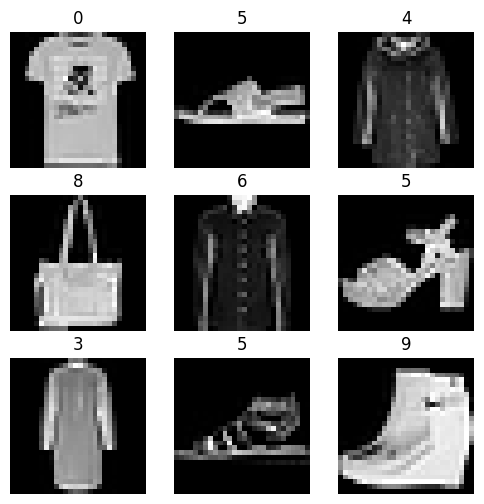

Training 2-Layer CNN
Epoch 1/5 Train: 76.72% Test: 82.82%
Epoch 2/5 Train: 85.29% Test: 85.51%
Epoch 3/5 Train: 87.69% Test: 87.62%
Epoch 4/5 Train: 88.78% Test: 87.96%
Epoch 5/5 Train: 89.58% Test: 89.04%


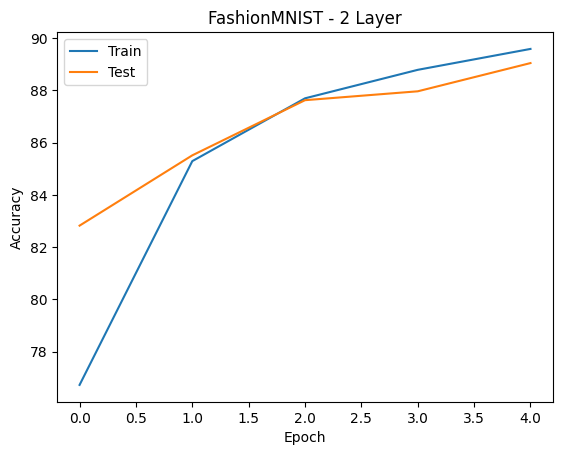

Training 4-Layer CNN
Epoch 1/5 Train: 77.72% Test: 84.85%
Epoch 2/5 Train: 86.90% Test: 87.15%
Epoch 3/5 Train: 89.00% Test: 89.07%
Epoch 4/5 Train: 90.35% Test: 90.00%
Epoch 5/5 Train: 91.57% Test: 90.80%


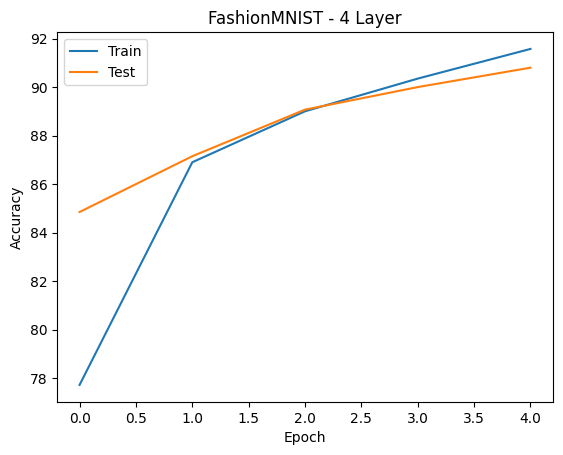

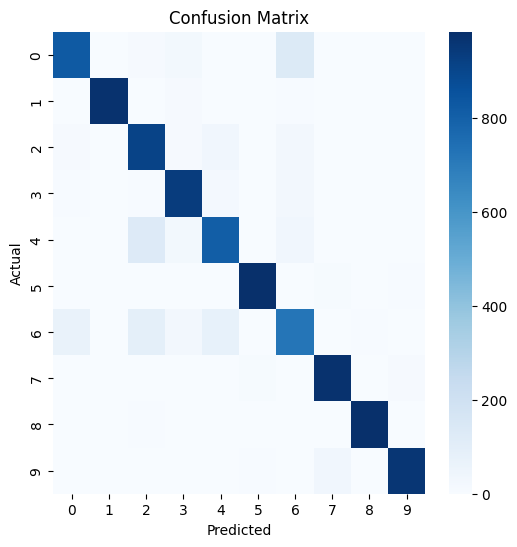

In [18]:
transform = transforms.ToTensor()

train_data = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

print("Sample Images:")
show_images(train_loader)

print("Training 2-Layer CNN")
model2 = CNN2(1, 10)
train_acc2, test_acc2 = train_model(model2, train_loader, test_loader)
plot_accuracy(train_acc2, test_acc2, "FashionMNIST - 2 Layer")

print("Training 4-Layer CNN")
model4 = CNN4(1, 10)
train_acc4, test_acc4 = train_model(model4, train_loader, test_loader)
plot_accuracy(train_acc4, test_acc4, "FashionMNIST - 4 Layer")

plot_confusion(model4, test_loader, 10)

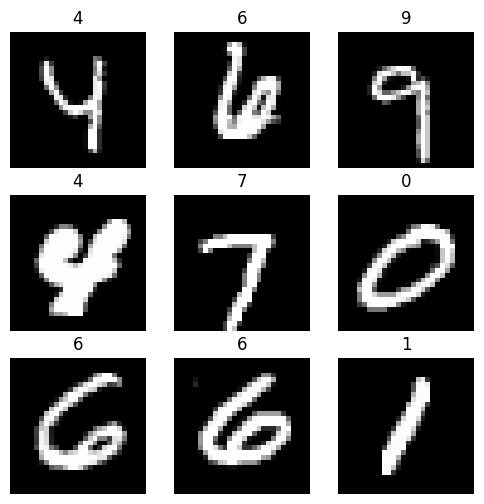

Epoch 1/5 Train: 89.43% Test: 96.51%
Epoch 2/5 Train: 96.90% Test: 97.89%
Epoch 3/5 Train: 97.72% Test: 98.26%
Epoch 4/5 Train: 98.19% Test: 98.14%
Epoch 5/5 Train: 98.50% Test: 98.55%


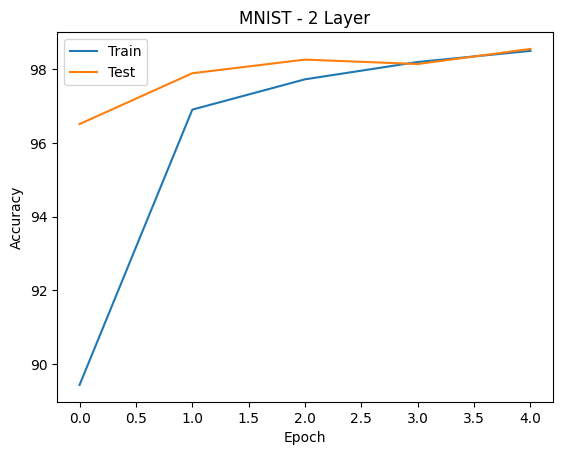

Epoch 1/5 Train: 92.14% Test: 98.07%
Epoch 2/5 Train: 98.13% Test: 98.53%
Epoch 3/5 Train: 98.68% Test: 98.88%
Epoch 4/5 Train: 98.91% Test: 98.68%
Epoch 5/5 Train: 99.09% Test: 98.61%


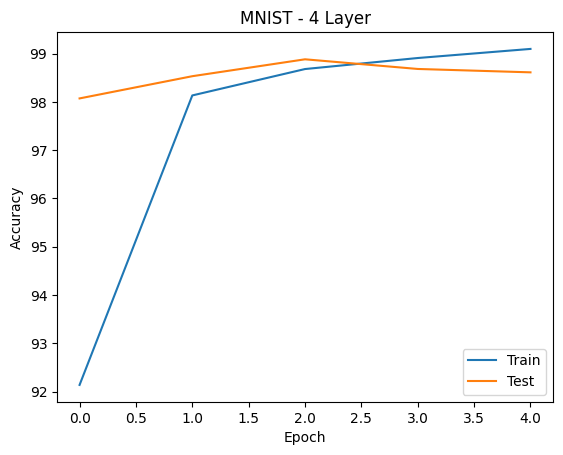

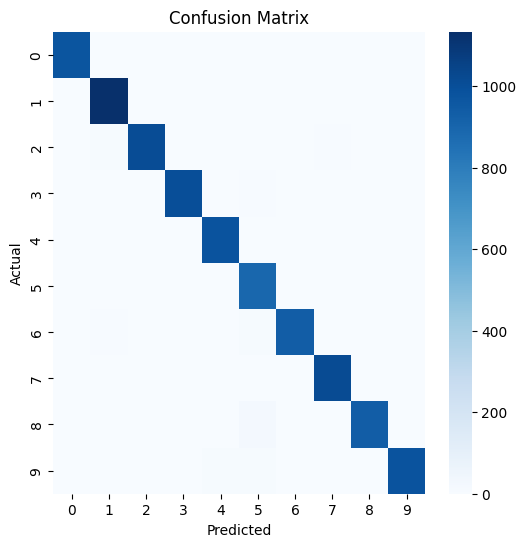

In [19]:
train_data = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

show_images(train_loader)

model2 = CNN2(1, 10)
train_acc2, test_acc2 = train_model(model2, train_loader, test_loader)
plot_accuracy(train_acc2, test_acc2, "MNIST - 2 Layer")

model4 = CNN4(1, 10)
train_acc4, test_acc4 = train_model(model4, train_loader, test_loader)
plot_accuracy(train_acc4, test_acc4, "MNIST - 4 Layer")

plot_confusion(model4, test_loader, 10)

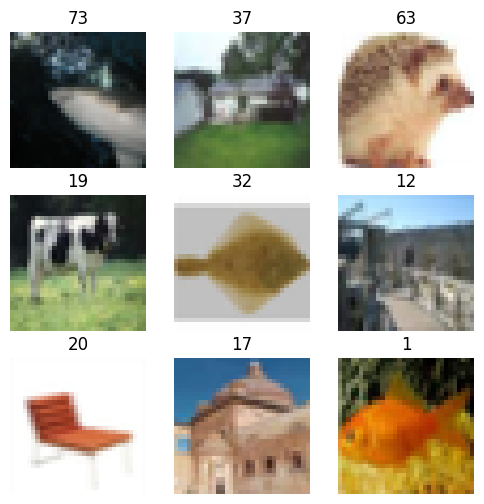

Epoch 1/5 Train: 10.84% Test: 17.51%
Epoch 2/5 Train: 20.64% Test: 23.69%
Epoch 3/5 Train: 25.53% Test: 26.96%
Epoch 4/5 Train: 28.70% Test: 29.47%
Epoch 5/5 Train: 30.98% Test: 29.86%


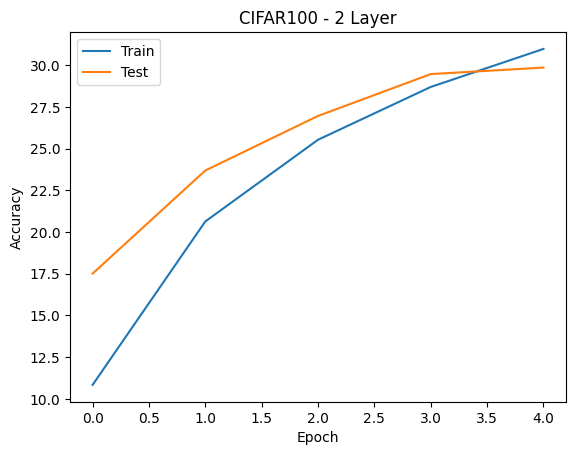

Epoch 1/5 Train: 10.92% Test: 19.32%
Epoch 2/5 Train: 22.70% Test: 26.40%
Epoch 3/5 Train: 29.32% Test: 29.72%
Epoch 4/5 Train: 34.23% Test: 34.15%
Epoch 5/5 Train: 38.13% Test: 36.71%


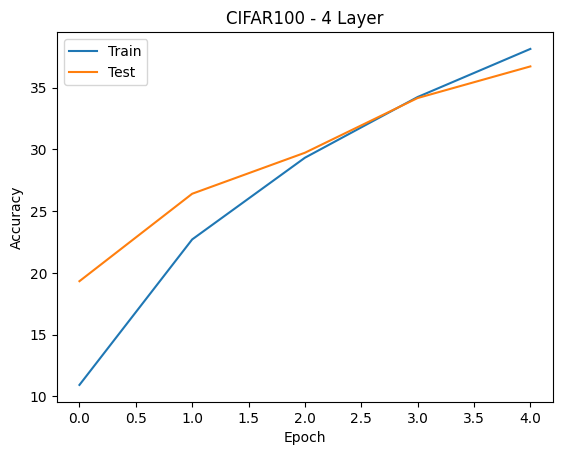

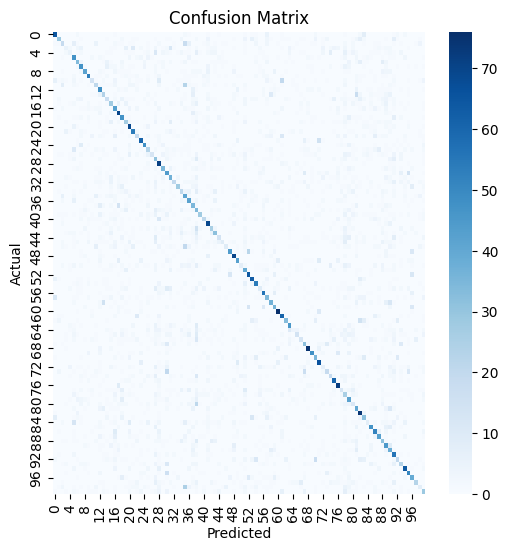

In [20]:
transform_cifar = transforms.ToTensor()

train_data = torchvision.datasets.CIFAR100('./data', train=True, download=True, transform=transform_cifar)
test_data = torchvision.datasets.CIFAR100('./data', train=False, transform=transform_cifar)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

show_images(train_loader)

model2 = CNN2(3, 100)
train_acc2, test_acc2 = train_model(model2, train_loader, test_loader)
plot_accuracy(train_acc2, test_acc2, "CIFAR100 - 2 Layer")

model4 = CNN4(3, 100)
train_acc4, test_acc4 = train_model(model4, train_loader, test_loader)
plot_accuracy(train_acc4, test_acc4, "CIFAR100 - 4 Layer")

plot_confusion(model4, test_loader, 100)

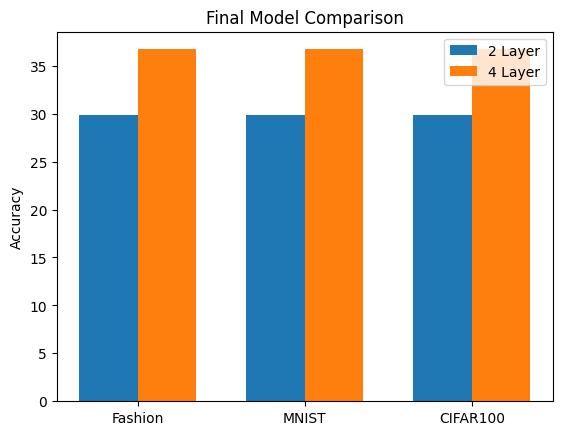

In [21]:
datasets = ["Fashion", "MNIST", "CIFAR100"]
acc_2layer = [test_acc2[-1], test_acc2[-1], test_acc2[-1]]
acc_4layer = [test_acc4[-1], test_acc4[-1], test_acc4[-1]]

x = np.arange(len(datasets))
width = 0.35

plt.figure()
plt.bar(x - width/2, acc_2layer, width)
plt.bar(x + width/2, acc_4layer, width)
plt.xticks(x, datasets)
plt.ylabel("Accuracy")
plt.legend(["2 Layer", "4 Layer"])
plt.title("Final Model Comparison")
plt.show()